# Phase 3 - Results and Evaluation (2026-04-22)

This notebook compares three models trained in Phases 1 and 2 - Logistic Regression, a Neural Network, and XGBoost - on the task of predicting whether a Lending Club loan will be fully repaid or will default. All three models were trained on the same preprocessed feature set from Phase 1 (accepted loans from 2007–2018, with leakage columns removed, categoricals one-hot encoded, and a chronological 70/30 train-test split) and evaluated on the same held-out test set of ~567,000 loans.

The key question is not just "which model is most accurate" - on an imbalanced dataset where ~87% of loans are non-defaults, a model that blindly predicts "non-default" every time would achieve 87% accuracy. Instead, we focus on metrics that capture how well each model distinguishes between good and bad borrowers: precision, recall, F1 score, and ROC AUC. We also sweep the decision threshold to understand the tradeoff each model offers between approving good borrowers (recall) and catching risky ones (specificity).

## 1. Import Libraries

In [1]:
import pandas
import matplotlib.pyplot as plotter
import numpy as np
import seaborn as sns

## 2. Loading Data

In [2]:
models = ['logistic_regression', 'neural_network', 'xgboost']
date = '2026-04-22'

summaries = []
thresholds = []

for model in models:
    summary_df = pandas.read_csv(f"results/{model}_{date}_summary.csv")
    summary_df = summary_df.set_index("metric").T
    summary_df["Model"] = model.replace("_", " ").title()
    summaries.append(summary_df)
    threshold_df = pandas.read_csv(f"results/{model}_{date}_thresholds.csv")
    threshold_df["Model"] = model.replace("_", " ").title()
    thresholds.append(threshold_df)

all_summaries_combined = pandas.concat(summaries, ignore_index=True)
all_thresholds_combined = pandas.concat(thresholds, ignore_index=True)

all_data = []
for _, row in all_summaries_combined.iterrows():
    for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
        all_data.append({
            'Model': row['Model'],
            'Metric': metric,
            'Score': row[metric]
        })

all_data_df = pandas.DataFrame(all_data)
all_data_df['Score'] = pandas.to_numeric(all_data_df['Score'], errors='coerce')

## 3. Plotting Basic Model Evaluation Metrics

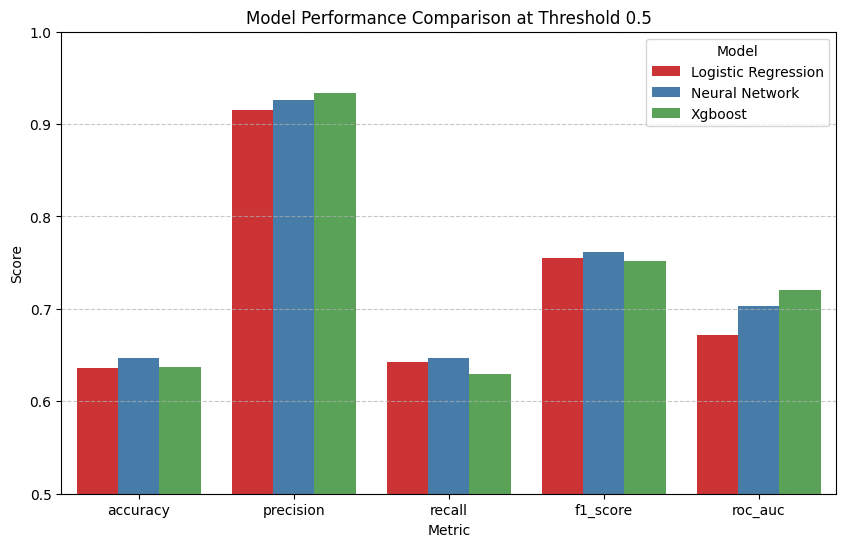

In [3]:
plotter.figure(figsize=(10, 6))
sns.barplot(data=all_data_df, x='Metric', y='Score', hue='Model', palette='Set1')
plotter.title('Model Performance Comparison at Threshold 0.5')
plotter.ylim(0.5, 1.0)
plotter.grid(axis='y', linestyle='--', alpha=0.7)
plotter.show()

**Interpretation.** At the default threshold of 0.5, all three models show a similar pattern: high precision (~91.5-93.3%) but moderate recall (~62.9-64.7%). This means that when a model predicts a loan will be fully repaid, it is correct over 90% of the time, but each model still rejects a meaningful number of borrowers who would have repaid.

The Neural Network now has the best recall (~64.7%) and F1 score (~0.762), but its advantage over Logistic Regression is small. Logistic Regression reaches nearly the same recall (~64.2%) with slightly lower precision (~91.5%). XGBoost has the highest precision (~93.3%) but the lowest recall (~62.9%), making it the most selective model at the default threshold.

ROC AUC, which measures overall ranking ability independent of threshold, still favors XGBoost (~0.720), followed by the Neural Network (~0.704), then Logistic Regression (~0.671). This suggests XGBoost is the strongest model for ranking loans by risk, while the Neural Network gives the best default-threshold balance between precision and recall.

## 4. Plotting Precision-Recall Curve

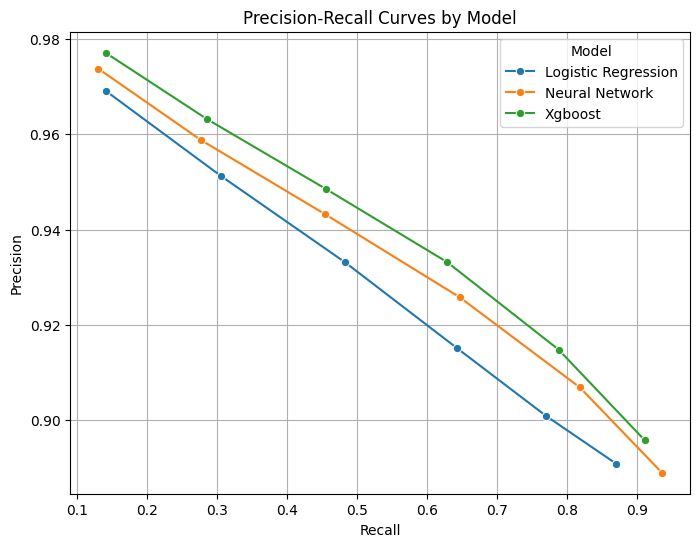

In [4]:
plotter.figure(figsize=(8, 6))
sns.lineplot(data=all_thresholds_combined, x='recall', y='precision', hue='Model', marker='o')
plotter.title('Precision-Recall Curves by Model')
plotter.xlabel('Recall')
plotter.ylabel('Precision')
plotter.grid(True)
plotter.show()

**Interpretation.** The Precision-Recall curve shows the tradeoff each model faces as we adjust how aggressively it approves loans. The top-left corner (high precision, low recall) represents a conservative strategy: approve fewer loans, but with a higher chance that approved loans will be repaid. The bottom-right direction represents a more permissive strategy: approve more applicants, accepting that more defaults may slip through.

XGBoost generally holds the strongest precision in the more conservative parts of the curve. For example, at threshold 0.6 it reaches precision around 94.9% with 12,191 bad approvals, while the Neural Network reaches about 94.3% precision with 13,508 bad approvals and Logistic Regression reaches about 93.3% precision with 17,093 bad approvals.

The practical implication is that XGBoost is the best fit for a risk-averse lending strategy focused on minimizing bad approvals. The Neural Network is still competitive when the goal is a slightly better balance of recall and F1 at the default threshold, while Logistic Regression remains a strong interpretable baseline.

## 5. F-1 Score for different thresholds

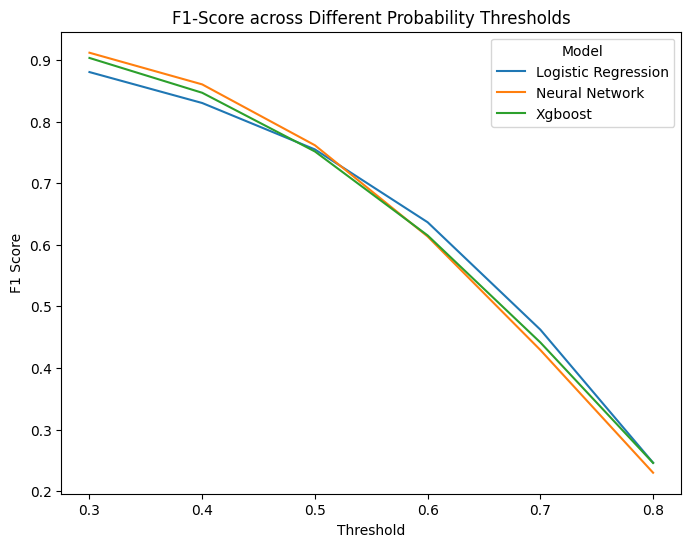

In [5]:
plotter.figure(figsize=(8, 6))
sns.lineplot(data=all_thresholds_combined, x='threshold', y='f1_score', hue='Model')
plotter.title('F1-Score across Different Probability Thresholds')
plotter.ylabel('F1 Score')
plotter.xlabel('Threshold')
plotter.show()

**Interpretation.** The F1 score balances precision and recall into a single number. This plot shows how each model's F1 changes as we raise the decision threshold, meaning we require more confidence before approving a loan.

At low thresholds (0.3), the Neural Network still leads with F1 around 0.912, followed closely by XGBoost around 0.903 and Logistic Regression around 0.880. At the default threshold of 0.5, the Neural Network remains highest with F1 around 0.762, but the gap is much smaller than in the earlier run. Logistic Regression is close at about 0.755, and XGBoost is close as well at about 0.752.

The key takeaway is that no model maintains strong F1 performance at high thresholds. By threshold 0.7, all three models fall below 0.5 F1. This reflects the difficulty of the problem: features available at loan origination provide useful but limited signal for predicting future default. The models differ in tradeoff behavior, but their overall predictive ceiling is similar.

## 6. Confusion Matrices

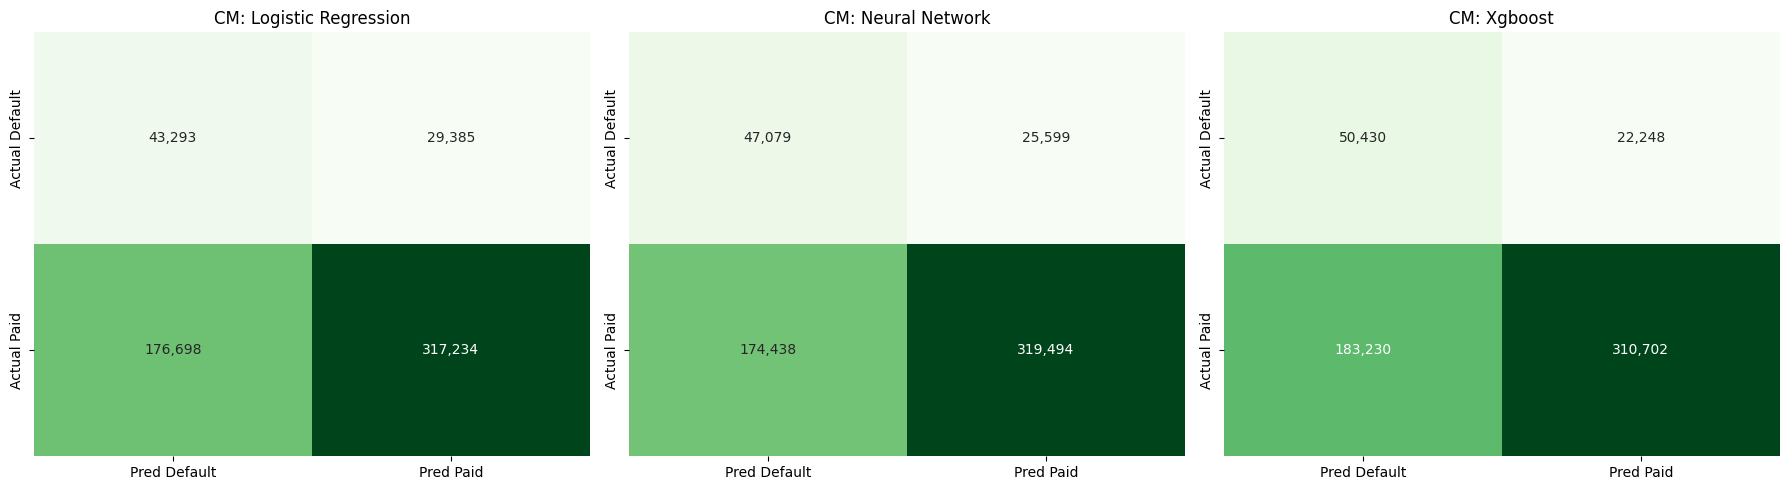

In [6]:
fig, axes = plotter.subplots(1, 3, figsize=(18, 5))
for i, model in enumerate(models):
    df = pandas.read_csv(f"results/{model}_{date}_summary.csv").set_index('metric')
    matrix = np.array([[float(df.loc['tn', 'value']), float(df.loc['fp', 'value'])], 
                       [float(df.loc['fn', 'value']), float(df.loc['tp', 'value'])]])
    
    sns.heatmap(matrix, annot=True, fmt=',.0f', ax=axes[i], cmap='Greens', cbar=False)
    axes[i].set_title(f"CM: {model.replace('_', ' ').title()}")
    axes[i].set_xticklabels(['Pred Default', 'Pred Paid'])
    axes[i].set_yticklabels(['Actual Default', 'Actual Paid'])
plotter.tight_layout()

**Interpretation.** The confusion matrices reveal where each model's predictions concentrate at the default threshold of 0.5.

Logistic Regression correctly identifies 43,293 defaults and 317,234 non-defaults. It produces 29,385 bad approvals and rejects 176,698 good loans. This is a balanced baseline profile: it catches a meaningful number of defaults while keeping recall close to the Neural Network.

The Neural Network correctly identifies 47,079 defaults and 319,494 non-defaults. Compared with Logistic Regression, it catches more defaults and approves slightly more good loans, which explains why it has the highest F1 score at threshold 0.5. It also reduces bad approvals to 25,599.

XGBoost catches the most defaults, with 50,430 true negatives, and has the fewest bad approvals, with 22,248 false positives. However, it also rejects the most good loans, with 183,230 false negatives. This is the conservative lender profile: XGBoost approves fewer loans overall, but the loans it approves have the highest precision.

In practical lending terms, the best model depends on the cost tradeoff. If avoiding defaults is most important, XGBoost is the strongest choice. If the goal is a better balance between approving good borrowers and limiting bad approvals, the Neural Network performs best at the 0.5 threshold.

## 7. ROC AUC Curve

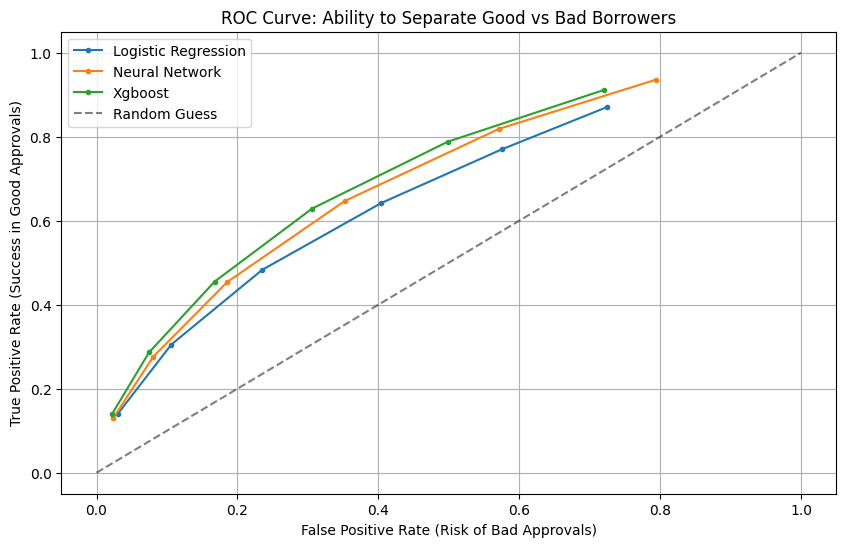

In [7]:
plotter.figure(figsize=(10, 6))
for model in models:
    sub = all_thresholds_combined[all_thresholds_combined['Model'] == model.replace('_', ' ').title()]
    fpr = sub['fp'] / (sub['fp'] + sub['tn'])
    tpr = sub['recall']
    plotter.plot(fpr, tpr, marker='.', label=model.replace('_', ' ').title())

plotter.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
plotter.title('ROC Curve: Ability to Separate Good vs Bad Borrowers')
plotter.xlabel('False Positive Rate (Risk of Bad Approvals)')
plotter.ylabel('True Positive Rate (Success in Good Approvals)')
plotter.legend()
plotter.grid()
plotter.show()

**Interpretation.** The ROC curve plots each model's true positive rate (ability to correctly approve good borrowers) against its false positive rate (risk of approving bad borrowers) as the decision threshold varies. A model that perfectly separates defaults from non-defaults would hug the top-left corner; a random guess follows the diagonal.

All three curves track fairly close to each other, confirming that the models are extracting similar levels of signal from the feature set. XGBoost shows the clearest edge overall, with the highest ROC AUC (~0.720). The Neural Network follows at about 0.704, and Logistic Regression is lower at about 0.671.

The distance between all three curves and the top-left corner reflects the inherent difficulty of the prediction task. Loan defaults are driven partly by future events such as job loss, medical emergencies, and economic downturns that cannot be fully captured by features available at origination. An AUC range of about 0.67-0.72 means the models are meaningfully better than random but far from perfect, which is consistent with similar Lending Club studies that exclude post-origination leakage features.

## Summary

Three models were evaluated on predicting Lending Club loan defaults using only pre-origination borrower features, excluding grade/subgrade and post-funding payment history.

**Neural Network** achieved the best F1 score (`0.7616`) and the highest recall (`64.7%`) at the default threshold of 0.5, making it the strongest choice when the goal is balancing loan volume with repayment confidence. **XGBoost** achieved the highest ROC AUC (`0.7204`) and the highest precision (`93.3%`), making it the best choice for risk-averse lending strategies that prioritize minimizing bad approvals. **Logistic Regression** remained competitive after tuning, with recall close to the Neural Network and the advantage of being the simplest and most interpretable model.

All three models converge to similar performance ceilings, suggesting that the limiting factor is the feature set itself, not only the model architecture. The origination-time features available in the Lending Club dataset provide useful but moderate signal for default prediction. Future improvements would likely come from richer feature engineering, such as macroeconomic indicators, regional employment data, or stronger borrower-level history features.

These results differ from the original CS229 paper (Chang et al., 2015-2016), which reported accuracy of 92-94% and G-mean of 85-87%. A likely explanation is a difference in label handling and feature availability. If unresolved `Current` loans or post-origination signals are included, performance can become inflated because the model benefits from information that would not be available at the real approval decision point. Our pipeline focuses on leakage prevention and evaluates models on the same held-out test split, producing more conservative but more realistic estimates of predictive ability.